In [13]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

points1=np.array([[3,3],[6,3],[6,6]])
points2=np.array([[9,3],[12,3],[9,6],[12,6],[9,9],[12,9]])
points3=np.array([[15,3],[18,3],[15,6],[18,6]])

new_points = np.array([[6.5,7], [8.5, 1], [13, 3.5]])

np_train=np.concatenate((points1,points2,points3))
print(np_train)
print(np_train.shape)

[[ 3  3]
 [ 6  3]
 [ 6  6]
 [ 9  3]
 [12  3]
 [ 9  6]
 [12  6]
 [ 9  9]
 [12  9]
 [15  3]
 [18  3]
 [15  6]
 [18  6]]
(13, 2)


In [14]:
np_label=np.array([0]*len(points1)+[1]*len(points2)+[2]*len(points3))
print(np_label)
print(np_label.shape)

[0 0 0 1 1 1 1 1 1 2 2 2 2]
(13,)


In [15]:
# 创建knn分类器
knn_clf_euclidean=KNeighborsClassifier(n_neighbors=2,metric='euclidean')

knn_clf_euclidean.fit(np_train,np_label)

KNeighborsClassifier(metric='euclidean', n_neighbors=2)

In [16]:
# 定义xy轴范围
axis=[0,12,0,20]
# 分别采样10个点
x_points=(axis[1]-axis[0])*100
y_points=(axis[3]-axis[2])*100
print(x_points)
print(y_points)

1200
2000


Text(0.5, 1.0, 'euclidean_distance')

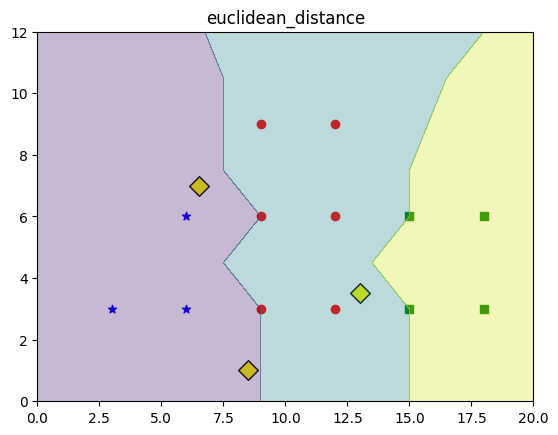

In [17]:
# 生成等差数列
x_sampling=np.linspace(axis[0],axis[1],x_points)
y_sampling=np.linspace(axis[2],axis[3],y_points)


# 对生成的数据进行变形，从一维数组变成二维列向量
x_grid=x_sampling.reshape(-1,1) # 参数-1表示自动计算行数，1表示列数为1
y_grid=y_sampling.reshape(-1,1)


# 生成坐标网络
x,y=np.meshgrid(y_grid,x_grid)

# 展平
x_ravel=x.ravel()
y_ravel=y.ravel()

# 合并
points=np.c_[x_ravel,y_ravel]

# 使用训练好的knn模型对坐标点进行预测
points_pre=knn_clf_euclidean.predict(points)
points_pre=points_pre.reshape(x.shape)



 # 绘制散点图
# 取出类别为0的数据
x0=np_train[np_label==0,0]
y0=np_train[np_label==0,1]

# 取出类别为1的数据
x1=np_train[np_label==1,0]
y1=np_train[np_label==1,1]

# 取出类别为2的数据
x2=np_train[np_label==2,0]
y2=np_train[np_label==2,1]

# 绘制0类别的样本散点图
plt.scatter(x0,y0,color='blue',label='class0',marker='*')
# 绘制1类别的样本散点图
plt.scatter(x1,y1,color='red',label='class1',marker='o')
# 绘制2类别的样本散点图
plt.scatter(x2,y2,color='green',label='class2',marker='s')

plt.scatter(new_points[:, 0], new_points[:, 1],
            c='yellow', marker='D', s=100,edgecolors='black')

qc=plt.contourf(x,y,points_pre,alpha=0.3)
plt.title('euclidean_distance')

Text(0.5, 1.0, 'manhattan_distance')

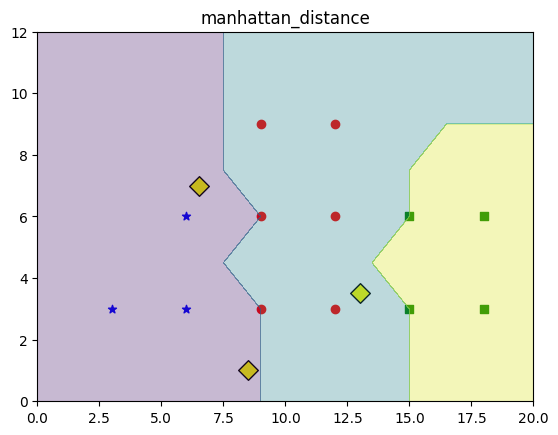

In [20]:
# 曼哈顿距离
# 创建knn分类器 曼哈顿距离
knn_clf_manhattan=KNeighborsClassifier(n_neighbors=2,metric='manhattan')

knn_clf_manhattan.fit(np_train,np_label)
# 定义xy轴范围
axis=[0,12,0,20]
# 分别采样100个点
x_points=(axis[1]-axis[0])*100
y_points=(axis[3]-axis[2])*100

# 生成等差数列
x_sampling=np.linspace(axis[0],axis[1],x_points)
y_sampling=np.linspace(axis[2],axis[3],y_points)

# 对生成的数据进行变形，从一维数组变成二维列向量
x_grid=x_sampling.reshape(-1,1) # 参数-1表示自动计算行数，1表示列数为1
y_grid=y_sampling.reshape(-1,1)

# 生成坐标网络
# x_grid 和 y_grid 是通过 np.linspace 生成的列向量
# np.meshgrid(x_grid, y_grid) 会生成两个二维数组，其中第一个参数作为列方向变化，第二个参数作为行方向变化
# 这导致生成的网格中，x坐标在列方向变化，y坐标在行方向变化
x,y=np.meshgrid(y_grid,x_grid)

# 展平
x_ravel=x.ravel()
y_ravel=y.ravel()
# 合并
points=np.c_[x_ravel,y_ravel]

# 使用训练好的knn模型对坐标点进行预测
points_pre=knn_clf_manhattan.predict(points)
points_pre=points_pre.reshape(x.shape)

 # 绘制散点图
# 取出类别为0的数据
x0=np_train[np_label==0,0]
y0=np_train[np_label==0,1]

# 取出类别为1的数据
x1=np_train[np_label==1,0]
y1=np_train[np_label==1,1]

# 取出类别为2的数据
x2=np_train[np_label==2,0]
y2=np_train[np_label==2,1]

# 绘制0类别的样本散点图
plt.scatter(x0,y0,color='blue',label='class0',marker='*')
# 绘制1类别的样本散点图
plt.scatter(x1,y1,color='red',label='class1',marker='o')
# 绘制2类别的样本散点图
plt.scatter(x2,y2,color='green',label='class2',marker='s')

plt.scatter(new_points[:, 0], new_points[:, 1],
            c='yellow', marker='D', s=100, edgecolors='black')

qc=plt.contourf(x,y,points_pre,alpha=0.3)
plt.title('manhattan_distance')